In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick


ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

In [3]:
bvals = np.linspace(10, 2000, 100)
bvecs = jax.random.normal(jax.random.PRNGKey(0), shape=(100, 3))
bvecs = bvecs / jnp.linalg.norm(bvecs, axis=-1, keepdims=True)

@jax.jit
def simulator(rng):
    rng1, rng2, rng3 = jax.random.split(rng, 3)
    alphas = jax.random.uniform(rng1, shape=(3,), minval=0.01, maxval=50.)
    theta = jax.random.normal(rng2, shape=(Ball2Stick.theta_dim,))
    model_mask = jax.random.bernoulli(rng3, p=0.5, shape=(3,))
    #model_mask = jnp.array([True, True, True])
    Ball2Stick.fraction_prior = alphas
    ball_stick = Ball2Stick.from_theta(theta, model_mask=model_mask)
    
    x_o = ball_stick.signal(bvals, bvecs)
    return alphas, model_mask, theta, x_o
    

In [4]:
from dmri.utils.transform import normal_to_dirichlet

normal_to_dirichlet(jnp.ones(3), jax.random.normal(jax.random.PRNGKey(3), shape=(2,)), mask=jnp.array([True, True, True]))

Array([0.26054338, 0.38181326, 0.35764337], dtype=float32)

In [5]:
Ball2Stick.fraction_prior = jnp.array([0.5, 0.5, 0.5])

Ball2Stick.from_theta(jax.random.normal(jax.random.PRNGKey(0), shape=(Ball2Stick.theta_dim,)))

In [6]:
from dmri.nn.tokenizer import StructuredTokenizer
from dmri.nn.autoregressive import ModelIdentificationDecoder
from flax import nnx

#tokenizer = StructuredTokenizer(dims_per_component, rngs=nnx.Rngs(0))
model = ModelIdentificationDecoder(rngs=nnx.Rngs(0), context_dim=130, num_layers=3, widening_factor=3)
params = nnx.state(model, nnx.Param)

In [7]:
alphas, masks, thetas, x_os = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(1), 100))

alphas = jnp.repeat(alphas, 10, axis=-1)
context = jnp.concatenate([alphas,x_os], axis=-1)


model(masks, context=context)

Array([[ 0.291,  0.287,  0.286],
       [ 0.297,  0.294,  0.295],
       [-0.175, -0.179, -0.177],
       [-0.182, -0.184, -0.184],
       [-0.387, -0.391, -0.393],
       [-0.182, -0.19 , -0.181],
       [ 0.034,  0.031,  0.031],
       [ 0.741,  0.732,  0.731],
       [-0.372, -0.375, -0.383],
       [-0.627, -0.635, -0.637],
       [-0.131, -0.144, -0.143],
       [ 0.892,  0.89 ,  0.888],
       [ 0.199,  0.195,  0.194],
       [-0.096, -0.146, -0.103],
       [ 0.226,  0.221,  0.221],
       [-0.698, -0.728, -0.751],
       [-1.11 , -1.124, -1.171],
       [ 0.773,  0.764,  0.765],
       [-0.106, -0.116, -0.123],
       [ 0.526,  0.518,  0.525],
       [ 0.91 ,  0.903,  0.908],
       [ 0.13 ,  0.114,  0.125],
       [-0.392, -0.396, -0.397],
       [-0.291, -0.295, -0.295],
       [-1.239, -1.242, -1.24 ],
       [-0.186, -0.188, -0.189],
       [ 0.279,  0.264,  0.264],
       [ 0.777,  0.773,  0.764],
       [ 0.217,  0.193,  0.188],
       [ 0.416,  0.396,  0.403],
       [-0

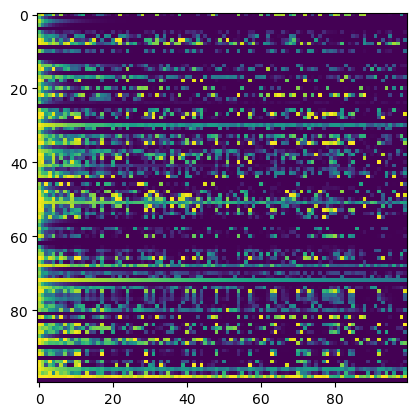

In [8]:
plt.imshow(x_os)

In [9]:
x_os

Array([[0.86 , 0.947, 0.412, ..., 0.   , 0.465, 0.   ],
       [0.685, 0.32 , 0.15 , ..., 0.   , 0.   , 0.   ],
       [0.89 , 0.704, 0.557, ..., 0.   , 0.   , 0.   ],
       ...,
       [0.946, 0.77 , 0.826, ..., 0.   , 0.009, 0.644],
       [1.   , 0.994, 0.995, ..., 0.95 , 0.713, 0.925],
       [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]], dtype=float32)

In [10]:
import optax

optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adamw(1e-3))

opt_state = optimizer.init(params)


def loss_fn(params, data, rng):
    nnx.update(model, params)
    alphas, components, thetas, xs = data
    alphas = jnp.repeat(alphas, 10, axis=-1)
    context = jnp.concatenate([alphas, xs], axis=-1)
    logits = model(components, context=context)

    loss =  optax.sigmoid_binary_cross_entropy(logits, components).sum(-1).mean()

    return loss

@jax.jit
def update(params, opt_state, data, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, data, rng)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state, loss

In [11]:
batch_simulator = jax.jit(jax.vmap(simulator))

In [12]:
%%timeit
batch_simulator(jax.random.split(jax.random.PRNGKey(1), 2**12))

724 ms ± 30.4 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [13]:
key = jax.random.PRNGKey(2)
for i in range(50):
    key, subkey1 = jax.random.split(key, 2) 
    alphas, masks, thetas, x_os = batch_simulator(jax.random.split(subkey1, 2**15))
    l = 0
    for j in range(100):
        key, subkey2 = jax.random.split(key, 2) 
        idx = jax.random.randint(subkey2, (512,), 0, 2**15)
        alphas_batch, masks_batch, thetas_batch, x_os_batch = alphas[idx], masks[idx], thetas[idx], x_os[idx]
        params, opt_state, loss = update(params, opt_state, (alphas_batch,masks_batch, thetas_batch, x_os_batch), subkey2)
        l += loss
    print(l/100) 

2.0626988
1.7220919
1.4297272
1.3386726
1.2216613
1.2272389
1.2162868
1.1332666
1.1344749
1.0610992
1.0455121
0.996017
0.9745527
0.94147635
0.9029256
0.8719097
0.8717933
0.854602
0.84026825
0.93678296
0.85687
0.80929035
0.7915619
0.78758144
0.7754735
0.76801926
0.82285106
0.749646
0.74324095
0.73913634
0.7246888
0.7717659
0.7088476
0.7122951
0.7146519
0.6879938
0.67615247
0.6875673
0.7015191
0.66980827
0.717425
0.6772903
0.67014754
0.66328
0.6588648
0.6589631
0.65421194
0.638237
0.63771015
0.6755254


In [14]:
nnx.update(model, params)

In [15]:
masks[:10]

Array([[False, False,  True],
       [False,  True, False],
       [ True,  True, False],
       [False,  True, False],
       [ True, False, False],
       [False,  True, False],
       [ True,  True,  True],
       [False,  True, False],
       [ True, False,  True],
       [False, False,  True]], dtype=bool)

In [16]:
alphas[0]

Array([25.895,  2.808, 17.103], dtype=float32)

In [43]:
alpha = jnp.array([1.,1.,10.])

context = jnp.concat([jnp.repeat(alpha, 10), x_os[0]])
context

Array([ 1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,
        1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,  1.   ,
        1.   ,  1.   ,  1.   ,  1.   , 10.   , 10.   , 10.   , 10.   ,
       10.   , 10.   , 10.   , 10.   , 10.   , 10.   ,  0.985,  0.96 ,
        0.505,  0.858,  0.864,  0.411,  0.999,  0.476,  0.044,  0.06 ,
        0.89 ,  1.   ,  0.255,  0.027,  0.003,  0.015,  0.403,  0.256,
        0.047,  0.029,  0.001,  0.918,  0.109,  0.075,  0.996,  0.017,
        0.   ,  0.157,  0.757,  0.008,  1.   ,  0.28 ,  0.032,  0.645,
        0.816,  0.   ,  0.001,  0.   ,  0.008,  0.253,  0.   ,  0.   ,
        0.816,  0.433,  0.73 ,  0.   ,  0.786,  0.747,  0.04 ,  0.   ,
        0.01 ,  0.   ,  0.   ,  0.   ,  0.11 ,  0.   ,  0.478,  0.776,
        0.606,  0.039,  0.881,  0.   ,  0.072,  0.   ,  0.12 ,  0.064,
        0.007,  0.644,  0.   ,  0.011,  0.   ,  0.   ,  0.423,  0.04 ,
        0.199,  0.035,  0.004,  0.001,  0.   ,  0.003,  0.034,  0.083,
      

In [44]:
alpha / alpha.sum()

Array([0.083, 0.083, 0.833], dtype=float32)

In [45]:
masks[0]

Array([False, False,  True], dtype=bool)

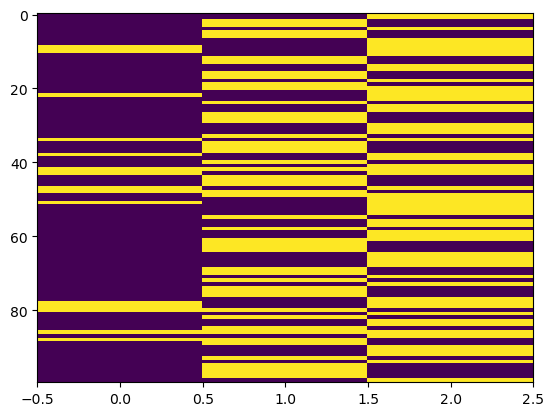

In [49]:
samples = jax.vmap(lambda k: model.sample(k, context,3))(jax.random.split(jax.random.PRNGKey(0), 100))
plt.imshow(samples, aspect='auto')